# 03 Exercise: Product Image Classification

In this exercise, you work with image data instead of tabular data. The business framing is product image classification for an online shop.

## Business Context

This is an optional exercise that extends the previous tabular examples to image data.

An online shop receives product images from different sources. Automatically assigning product categories can support catalog maintenance, quality checks, search, filtering, and downstream recommendation systems.

The workflow is still supervised learning:

- input data: product images,
- target variable: product category,
- model output: predicted product class,
- evaluation: compare predicted classes with known labels.

The main difference is the data representation. In the previous exercises, one row represented one customer or one tree. Here, one observation is an image made of pixel values.

## Dataset

Fashion-MNIST contains 70,000 grayscale product images with 10 classes.

The notebook downloads the data automatically into:

`data/raw/fashion_mnist/`

This directory is ignored by git and should not be committed.

Each image has shape `1 x 28 x 28`:

- `1`: one color channel because the images are grayscale,
- `28`: image height in pixels,
- `28`: image width in pixels.

A pixel is a small numeric value that represents image brightness. For this dataset, the transformation `transforms.ToTensor()` converts each image into a PyTorch tensor and scales pixel values to the range from 0 to 1.

## What Is a Tensor?

A tensor is a multi-dimensional array of numbers.

You can think of it as a generalization of familiar data structures:

- scalar: one number, for example `7`,
- vector: one-dimensional list of numbers, for example one feature row,
- matrix: two-dimensional table of numbers, for example a grayscale image,
- tensor: array with more dimensions, for example many images with channels.

For image classification in PyTorch, a batch of images usually has this shape:

`batch_size x channels x height x width`

Example:

`128 x 1 x 28 x 28`

This means: 128 images per batch, one grayscale channel, each image 28 pixels high and 28 pixels wide.

The model does not see a product image as a shirt or shoe. It only receives these numeric pixel values and learns patterns that are useful for predicting the class label.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

RANDOM_STATE = 42
BATCH_SIZE = 128
TRAIN_SUBSET_SIZE = 12_000
VALID_SIZE = 2_000
EPOCHS = 3

torch.manual_seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


In [2]:
def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data" / "raw").exists():
            return path
    raise FileNotFoundError("Could not find project root with data/raw directory.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "fashion_mnist"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Fashion-MNIST data directory: {DATA_DIR}")


Project root: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master
Fashion-MNIST data directory: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/data/raw/fashion_mnist


## 2. Load Data

The first run downloads Fashion-MNIST. Later runs reuse the local files.

We create three data loaders:

- training loader: used to update model weights,
- validation loader: used to check performance during training,
- test loader: used for final evaluation.

To keep this optional exercise fast, we train on a subset of the full training data.

In [3]:
transform = transforms.ToTensor()

train_dataset_full = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform,
)

class_names = train_dataset_full.classes
print(f"Training images: {len(train_dataset_full):,}")
print(f"Test images: {len(test_dataset):,}")
print(class_names)


  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  2%|▏         | 426k/26.4M [00:00<00:06, 4.23MB/s]

  4%|▍         | 1.15M/26.4M [00:00<00:04, 5.90MB/s]

  7%|▋         | 1.74M/26.4M [00:00<00:05, 4.88MB/s]

 11%|█         | 2.85M/26.4M [00:00<00:03, 7.05MB/s]

...

 93%|█████████▎| 4.10M/4.42M [00:00<00:00, 6.98MB/s]

100%|██████████| 4.42M/4.42M [00:00<00:00, 6.69MB/s]

  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 8.05MB/s]

Training images: 60,000
Test images: 10,000
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [4]:
generator = torch.Generator().manual_seed(RANDOM_STATE)
subset_indices = torch.randperm(len(train_dataset_full), generator=generator)[:TRAIN_SUBSET_SIZE]
train_dataset_small = Subset(train_dataset_full, subset_indices)

train_size = TRAIN_SUBSET_SIZE - VALID_SIZE
train_subset, valid_subset = random_split(
    train_dataset_small,
    [train_size, VALID_SIZE],
    generator=generator,
)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Images used for training: {len(train_subset):,}")
print(f"Images used for validation: {len(valid_subset):,}")
print(f"Images used for testing: {len(test_dataset):,}")


Images used for training: 10,000
Images used for validation: 2,000
Images used for testing: 10,000


## 3. Visualize Sample Images

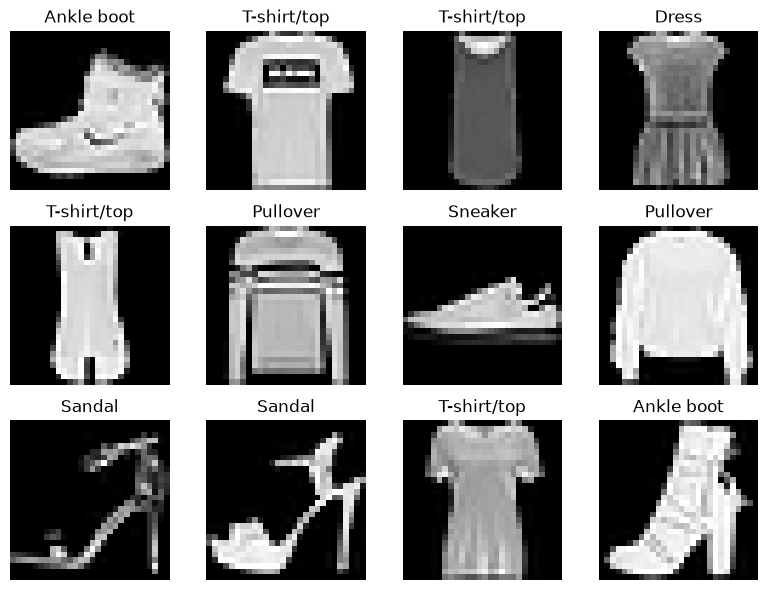

In [5]:
def show_sample_images(dataset, class_names, n_images: int = 12) -> None:
    fig, axes = plt.subplots(3, 4, figsize=(8, 6))
    for ax, idx in zip(axes.ravel(), range(n_images)):
        image, label = dataset[idx]
        ax.imshow(image.squeeze(), cmap="gray")
        ax.set_title(class_names[label])
        ax.axis("off")
    plt.tight_layout()
    plt.show()


show_sample_images(train_dataset_full, class_names)


## 4. Model Definition

The model below is intentionally simple.

It first flattens each `28 x 28` image into one long vector with `784` values. Then it passes the vector through a few fully connected layers.

This is not the strongest architecture for image data. Convolutional neural networks and pretrained models usually perform better. The goal here is to make the basic mechanics visible:

- image tensor goes in,
- model computes class scores,
- loss compares scores with true labels,
- optimizer updates model weights.

In [6]:
class ProductImageClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.network(x)


model = ProductImageClassifier().to(DEVICE)
model


ProductImageClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

## 5. Training and Evaluation Helpers

In [7]:
def train_one_epoch(model, data_loader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate_loader(model, data_loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = loss_fn(logits, labels)

            total_loss += loss.item() * images.size(0)
            predictions = logits.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    return {
        "loss": total_loss / total,
        "accuracy": correct / total,
        "y_true": np.array(y_true),
        "y_pred": np.array(y_pred),
    }


## 6. Train the Model

Training means repeatedly showing batches of labeled images to the model.

For each batch:

1. the model predicts class scores,
2. the loss function measures how wrong the prediction is,
3. backpropagation calculates how model weights should change,
4. the optimizer updates the weights.

One pass through the training data is called an epoch. We use only a few epochs so the notebook stays lightweight.

In [8]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# TODO: Train the model for a few epochs.
# history = []
# for epoch in range(1, EPOCHS + 1):
#     train_loss, train_accuracy = train_one_epoch(model, train_loader, loss_fn, optimizer, DEVICE)
#     valid_result = evaluate_loader(model, valid_loader, loss_fn, DEVICE)
#     history.append({
#         "epoch": epoch,
#         "train_loss": train_loss,
#         "train_accuracy": train_accuracy,
#         "valid_loss": valid_result["loss"],
#         "valid_accuracy": valid_result["accuracy"],
#     })
#     print(f"Epoch {epoch}: train_acc={train_accuracy:.3f}, valid_acc={valid_result['accuracy']:.3f}")
#
# history_df = pd.DataFrame(history)
# history_df

## 7. Test Evaluation

In [9]:
# TODO: Evaluate the trained model on the test set.
# test_result = evaluate_loader(model, test_loader, loss_fn, DEVICE)
# y_true = test_result["y_true"]
# y_pred = test_result["y_pred"]
# {
#     "accuracy": accuracy_score(y_true, y_pred),
#     "macro_f1": f1_score(y_true, y_pred, average="macro"),
# }

## 8. Confusion Matrix and Error Analysis

In [10]:
# TODO: Create a classification report and confusion matrix.
# print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
# ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=class_names, xticks_rotation=45)
# plt.show()

In [11]:
# TODO: Show a few misclassified product images.
# This helps connect numerical errors to actual image examples.

## Practice Note: Transfer Learning

In real-world image classification, teams usually do not train a small neural network from scratch.

A common production approach is transfer learning:

1. Start with a pretrained model such as ResNet, EfficientNet, MobileNet, ConvNeXt, or a Vision Transformer.
2. Use a model that has already learned visual patterns from a large dataset such as ImageNet.
3. Replace the final classification layer with a new layer for the project-specific classes.
4. Train only the new head first, or fine-tune parts of the full model with a small learning rate.

This is practical because real image datasets are often expensive to label. A pretrained model already understands general visual structures such as edges, textures, shapes, and object parts. Fine-tuning adapts these generic visual features to the specific domain, for example product photos from one online shop.

Training from scratch is usually considered when very large labeled datasets are available, when the image domain is very different from common pretrained data, or when there are strict technical constraints.

In this exercise, the small model is used for learning purposes. It makes tensors, training loops, loss, evaluation, and visual error analysis easier to inspect.

## 10. Reflection

Questions:

- Which product classes are confused most often?
- Would accuracy alone be sufficient for an online-shop workflow?
- What would change with real product images?
- Why might transfer learning be more appropriate in practice?
- What would need to be monitored in production?